# PCOS Detection using CNN (Day 1: Data Understanding)

This notebook focuses on exploring and understanding the PCOS ultrasound dataset before model training.

## Objectives
- Load and explore dataset structure
- Analyze class distribution
- Visualize sample ultrasound images
- Identify data quality issues

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/pcos-dataset/archive (3).zip"

Streaming output truncated to the last 5000 lines.
  inflating: PCOS/noninfected/Image_001.jpg  
  inflating: PCOS/noninfected/Image_002.jpg  
  inflating: PCOS/noninfected/Image_003.jpg  
  inflating: PCOS/noninfected/Image_004.jpg  
  inflating: PCOS/noninfected/Image_005.jpg  
  inflating: PCOS/noninfected/Image_006.jpg  
  inflating: PCOS/noninfected/Image_007.jpg  
  inflating: PCOS/noninfected/Image_008.jpg  
  inflating: PCOS/noninfected/Image_009.jpg  
  inflating: PCOS/noninfected/Image_010.jpg  
  inflating: PCOS/noninfected/Image_011.jpg  
  inflating: PCOS/noninfected/Image_012.jpg  
  inflating: PCOS/noninfected/Image_013.jpg  
  inflating: PCOS/noninfected/Image_014.jpg  
  inflating: PCOS/noninfected/Image_015.jpg  
  inflating: PCOS/noninfected/Image_016.jpg  
  inflating: PCOS/noninfected/Image_017.jpg  
  inflating: PCOS/noninfected/Image_018.jpg  
  inflating: PCOS/noninfected/Image_019.jpg  
  inflating: PCOS/noninfected/Image_020.jpg  
  inflating: PCOS/noninfected

In [3]:
import os
os.listdir()

['.config', 'PCOS', 'drive', 'sample_data']

## Dataset Description

- Dataset: PCOS-XAI Ultrasound Dataset
- Total Images: ~11,784
- Classes:
  - infected (PCOS)
  - noninfected (Healthy)

In [5]:
dataset_path = 'PCOS'
os.listdir(dataset_path)

['noninfected', 'infected']

In [6]:
for cls in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, cls)
    print(cls, ":", len(os.listdir(folder)))

noninfected : 5000
infected : 6784


## Sample Image Visualization

We display random ultrasound images from each class to understand visual patterns and differences.

This helps in:
- Understanding image quality
- Identifying noise or blur
- Observing class characteristics

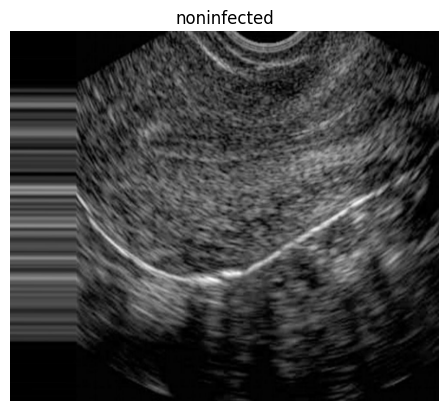

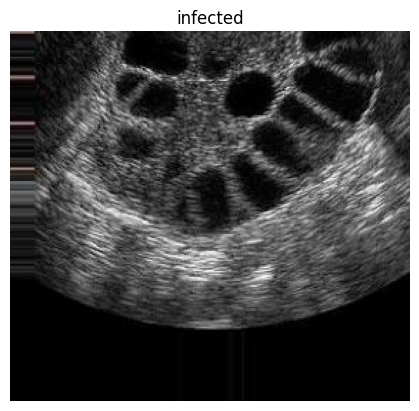

In [7]:
import cv2
import matplotlib.pyplot as plt
import random

classes = os.listdir(dataset_path)

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()

## Class Distribution Analysis

We analyze the number of images in each class to check for imbalance.

Class imbalance can lead to biased model predictions, so it is important to identify it early.

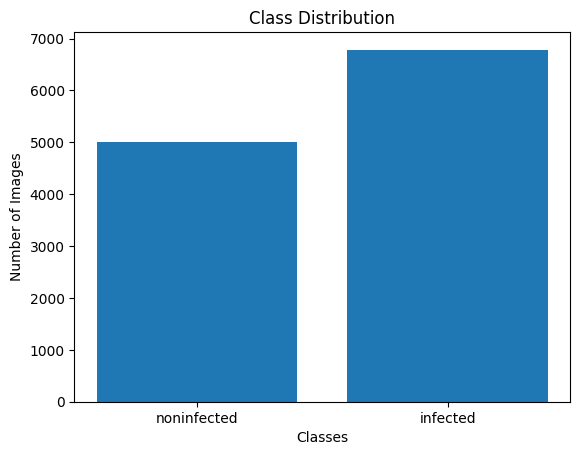

In [9]:
import matplotlib.pyplot as plt

classes = os.listdir(dataset_path)
counts = [len(os.listdir(os.path.join(dataset_path, cls))) for cls in classes]

plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [10]:
total = sum(counts)
for cls, count in zip(classes, counts):
    print(f"{cls}: {round((count/total)*100, 2)}%")

noninfected: 42.43%
infected: 57.57%


## Image Resolution Analysis

The dataset contains images of varying sizes.

This is important because:
- CNN models require fixed-size inputs
- Images must be resized before training

In [8]:
from PIL import Image
import os

sizes = []

for cls in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, cls)
    for img_name in os.listdir(folder)[:50]:  # sample
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)

print(set(sizes))

{(848, 984), (171, 171), (289, 300), (233, 216), (242, 289), (850, 578), (315, 160), (436, 630), (247, 239), (300, 300), (216, 233), (275, 255), (263, 238), (247, 272), (320, 320), (293, 214), (578, 850), (258, 226), (257, 300), (343, 343), (630, 436), (116, 108), (984, 848), (280, 259), (299, 266), (250, 258), (273, 259), (225, 225), (285, 300), (244, 229), (160, 315)}


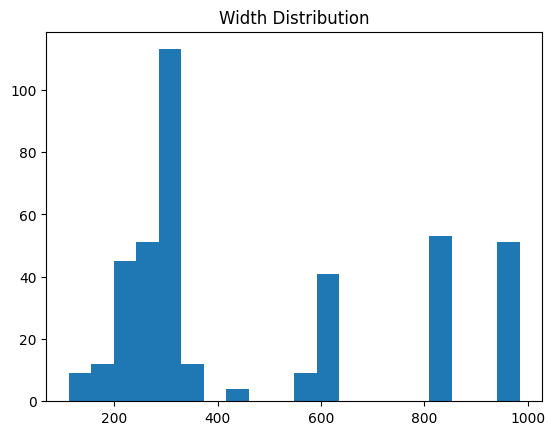

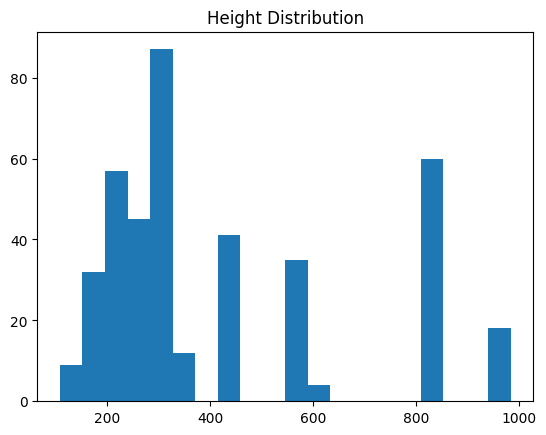

In [11]:
widths = []
heights = []

for cls in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, cls)
    for img_name in os.listdir(folder)[:200]:
        img = Image.open(os.path.join(folder, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.hist(widths, bins=20)
plt.title("Width Distribution")
plt.show()

plt.hist(heights, bins=20)
plt.title("Height Distribution")
plt.show()

### Sample Grid Visualization



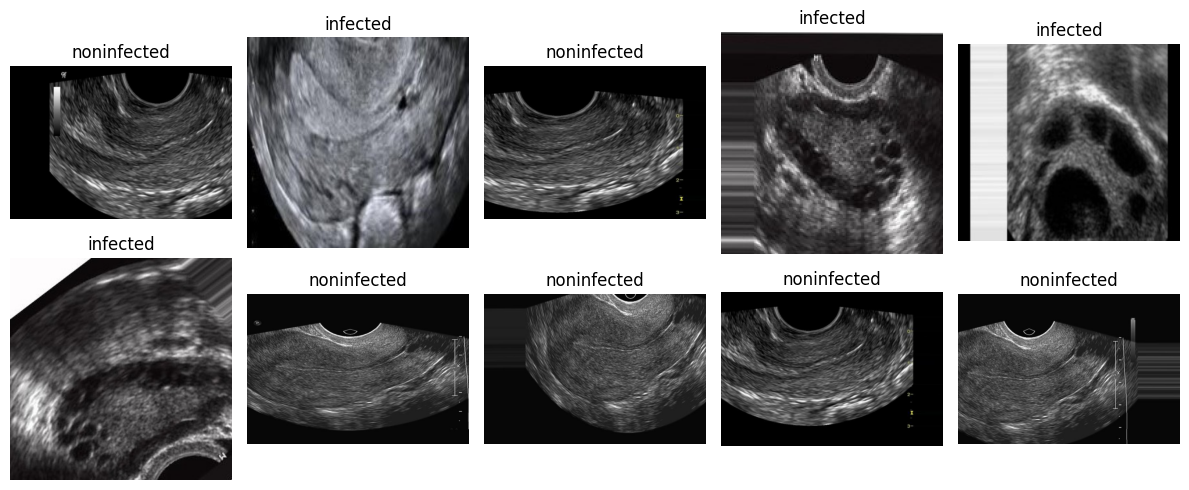

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i, ax in enumerate(axes.flat):
    cls = random.choice(classes)
    folder = os.path.join(dataset_path, cls)
    img_name = random.choice(os.listdir(folder))
    img = cv2.imread(os.path.join(folder, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Final Observations

- Dataset contains ~11,784 ultrasound images
- Slight class imbalance exists
- Images have varying resolutions
- Presence of noise and blur
- High risk of duplicate images → potential data leakage
